## Librerias

In [135]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [136]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [137]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [138]:
# Cuantos partidos se jugaron?
# Completar
partidos = mundial["match_no"].sum()
partidos


np.int64(2080)

In [139]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar
mundial.info()
mundial.describe()
mundial.columns
mundial.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   match_no                         64 non-null     int64  
 1   day_of_week                      64 non-null     object 
 2   date                             64 non-null     object 
 3   hour                             64 non-null     object 
 4   venue                            64 non-null     object 
 5   referee                          64 non-null     object 
 6   group                            64 non-null     object 
 7   1                                64 non-null     object 
 8   2                                64 non-null     object 
 9   attendance                       64 non-null     int64  
 10  1_xg                             64 non-null     float64
 11  2_xg                             64 non-null     float64
 12  1_poss                  

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361


## Analisis

### Primera Parte

In [140]:
# Cuantas selecciones participaron?
# Completar
selecciones = pd.concat([mundial['1'], mundial['2']]).unique().size
selecciones

32

In [141]:
# Cuantas fases tiene el mundial?
# Completar

fases = mundial['group'].unique()
fases_totales = len(fases) # len() nos da la cantidad de elementos en el array de fases únicas
fases = fases_totales
fases

13

In [142]:
# Cual fue la "attendance" promedio por partido?
# Completar
promedio = mundial['attendance'].mean()
promedio

np.float64(53191.4375)

In [143]:
# Cual fue el partido con mas diferencia de goles?
# Completar
columnas_selecciones= ["1","2"]
mundial.loc[(mundial["1_goals"]- mundial["2_goals"]).abs().idxmax(), columnas_selecciones]

,10
1,SPAIN
2,COSTA RICA


In [144]:
# Cual es la selección que mas penales metió?
# Completar

penales1 = mundial.groupby('1')['1_panelties_scored'].sum()
penales2 = mundial.groupby('2')['2_panelties_scored'].sum()
penales = pd.concat([penales1, penales2]).groupby(level=0).sum()
penales.idxmax()

'ARGENTINA'

In [145]:
# Cual es la selección que mas penales le hicieron?
# Completar
penales1 = mundial.groupby('1')['2_panelties_scored'].sum()
penales2 = mundial.groupby('2')['1_panelties_scored'].sum()
penales = pd.concat([penales1, penales2]).groupby(level=0).sum()
penales.idxmax()

'FRANCE'

### Segunda Parte

In [146]:
equipo : str = "ARGENTINA"

In [147]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar

filtroLocal : pd.Series = mundial['1'] == equipo
partidos_local = mundial[filtroLocal]
partidos_local

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409


In [148]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar

filtroVisitante : pd.Series = mundial['2'] == equipo
partidos_visitante = mundial[filtroVisitante]
partidos_visitante

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323


In [149]:
# Seleccionar todos los partidos que jugo el equipo (de "local" o "visitante")
# Completar

partidos : pd.DataFrame = pd.concat([partidos_local, partidos_visitante])
partidos

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323


In [150]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
# Completar

goles : int = mundial[mundial["1"] == equipo]['1_goals'].sum() + mundial[mundial["2"] == equipo]['2_goals'].sum()

goles

np.int64(15)

In [151]:
# Cuantos goles hizo el equipo en promedio
# Completar

promedio_goles : int = goles / len(partidos)
promedio_goles

np.float64(2.142857142857143)

In [152]:
ganados : int = (partidos_local['1_goals'] > partidos_local['2_goals']).sum() + \
               (partidos_visitante['2_goals'] > partidos_visitante['1_goals']).sum()
ganados

np.int64(4)

In [153]:
goles

np.int64(15)

In [154]:
goles_equipo_ord = pd.concat([mundial[mundial["1"] == equipo]['1_goals'], mundial[mundial["2"] == equipo]['2_goals']]).sort_index()
goles_equipo_ord

,0
4,1
23,2
38,2
49,2
57,2
60,3
63,3


<BarContainer object of 7 artists>

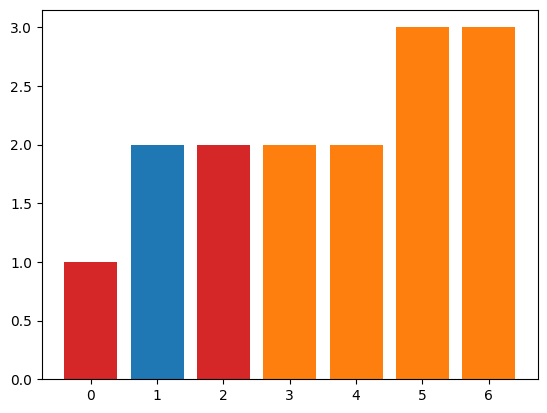

In [155]:
# Graficar los goles hechos por el equipo en cada partido

fig, ax = plt.subplots()
fruits = list(range(goles_equipo_ord.size))
counts = goles_equipo_ord.values
bar_labels = goles_equipo_ord.index
bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange','tab:orange','tab:orange','tab:orange']
ax.bar(fruits, counts,  color=bar_colors)
# Completar

### Tercera Parte

In [156]:
import pandas as pd

equipos = pd.concat([mundial['1'], mundial['2']]).unique()
goles_por_equipo = {}

for equipo_nombre in equipos:
    goles_local = mundial[mundial['1'] == equipo_nombre]['1_goals'].sum()
    goles_visitante = mundial[mundial['2'] == equipo_nombre]['2_goals'].sum()
    goles_por_equipo[equipo_nombre] = goles_local + goles_visitante

goles = pd.Series(goles_por_equipo)
goles

,0
QATAR,1
ENGLAND,13
SENEGAL,5
UNITED STATES,3
ARGENTINA,15
DENMARK,1
MEXICO,2
FRANCE,16
MOROCCO,6
GERMANY,6


<BarContainer object of 32 artists>

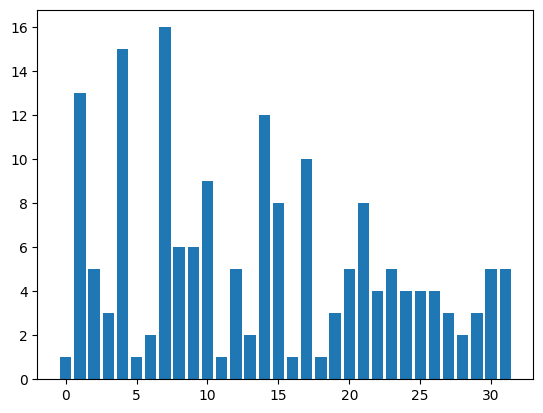

In [157]:
# Graficar los goles por equipo en todo el mundial
fig, ax = plt.subplots()
fruits = list(range(goles.size))
counts = goles.values
bar_labels = goles.index

ax.bar(fruits, counts)
# Completar
# Completar

In [158]:
# Cual es el equipo que hizo mas goles en el mundial?
goles.idxmax()
# Completar

'FRANCE'

In [159]:
# Por cada partido, cual fue la diferencia de goles?
# Completar
diferencia_goles = mundial['1_goals'] - mundial['2_goals']
abs(diferencia_goles)

,0
0,2
1,4
2,2
3,0
4,1
...,...
59,1
60,3
61,2
62,1


In [160]:
# Por cada partido, cual fue el equipo que gano?
# Completar
ganados =0
perdidos=0
for i in range(len(mundial)):
 if mundial['1_goals'][i]> mundial['2_goals'][i]:
    ganados=ganados+1
 elif  mundial['2_goals'][i]> mundial['1_goals'][i]:
    perdidos=perdidos +1
print(ganados)
print(perdidos)


29
20


In [161]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles? goles_por_fase = {}

for fase in mundial['group'].unique():

    df_fase = mundial[mundial['group'] == fase]

    goles_en_fase = {}
    for equipo_nombre in equipos:
        goles_local = df_fase[df_fase['1'] == equipo_nombre]['1_goals'].sum()
        goles_visitante = df_fase[df_fase['2'] == equipo_nombre]['2_goals'].sum()
        goles_en_fase[equipo_nombre] = goles_local + goles_visitante


    if goles_en_fase:
        equipo_mas_goles = max(goles_en_fase, key=goles_en_fase.get)
        max_goles = goles_en_fase[equipo_mas_goles]
        goles_por_fase[fase] = {'equipo': equipo_mas_goles, 'goles': max_goles}

for fase, data in goles_por_fase.items():
    print(f"Fase: {fase} - Equipo con más goles: {data['equipo']} ({data['goles']} goles)")
# Completar

Fase: Group A - Equipo con más goles: SENEGAL (5 goles)
Fase: Group B - Equipo con más goles: ENGLAND (9 goles)
Fase: Group C - Equipo con más goles: ARGENTINA (5 goles)
Fase: Group D - Equipo con más goles: FRANCE (6 goles)
Fase: Group F - Equipo con más goles: MOROCCO (4 goles)
Fase: Group E - Equipo con más goles: SPAIN (9 goles)
Fase: Group G - Equipo con más goles: SERBIA (5 goles)
Fase: Group H - Equipo con más goles: PORTUGAL (6 goles)
Fase: Round of 16 - Equipo con más goles: PORTUGAL (6 goles)
Fase: Quarter-final - Equipo con más goles: ARGENTINA (2 goles)
Fase: Semi-Final - Equipo con más goles: ARGENTINA (3 goles)
Fase: Play-off for third place - Equipo con más goles: CROATIA (2 goles)
Fase: Final - Equipo con más goles: ARGENTINA (3 goles)


### Tercera Parte

In [162]:


equipocampeones : str = ["ARGENTINA","BRAZIL","FRANCE","ENGLAND","URUGUAY","SPAIN","GERMANY"]
goles_campeones = {}
for equipo in equipocampeones:
        if equipo in goles.index:
            goles_campeones[equipo] = goles[equipo]
goles_campeones

{'ARGENTINA': np.int64(15),
 'BRAZIL': np.int64(8),
 'FRANCE': np.int64(16),
 'ENGLAND': np.int64(13),
 'URUGUAY': np.int64(2),
 'SPAIN': np.int64(9),
 'GERMANY': np.int64(6)}

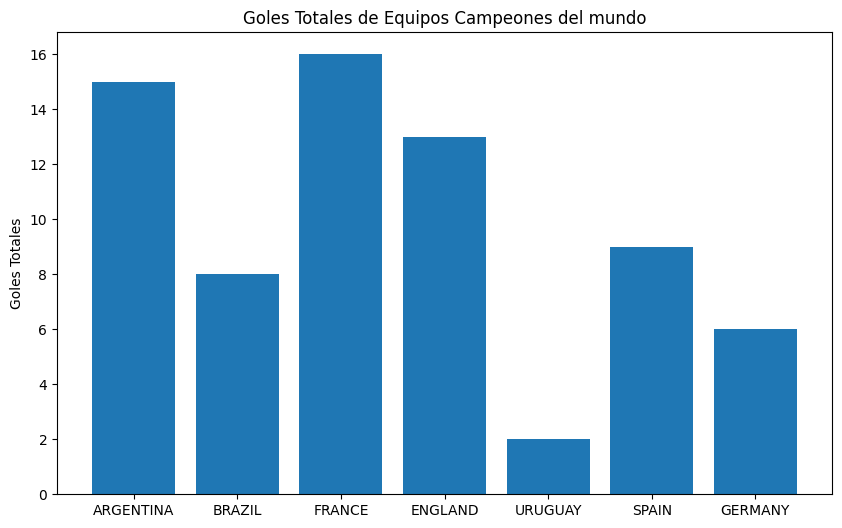

In [163]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_labels = list(goles_campeones.keys())
counts = list(goles_campeones.values())
ax.bar(bar_labels, counts)
ax.set_ylabel('Goles Totales')
ax.set_title('Goles Totales de Equipos Campeones del mundo')

plt.show()
